# Image processing

## Convolution


**Convolution** is a common method used in image processing to apply blurring, sharpening, embossing and edge detection to an image. Given an input image we can apply convolution using a **kernel** (or filter) on the input to produce an output image that has the kernel applied. 

The convolution of an image array $X$ and a kernel array $Y$ is

```{math}
:label: convolution-equation

\begin{align*}
	Y(i,j) = K * X(i,j) = \sum_{p = -a}^{a} \sum_{q = -b}^{b} K(i-p,j-q) X(p,q) 
\end{align*}
```

where $Y$ is the filtered image, $X$ is the original image, $K$ is a kernel filter. $K$ is usually a square matrix with odd numbers of rows and columns. To calculate the filtered image we align the kernel filter with elements of $X$, multiply the corresponding elements together and sum the result. For example consider the convolution of the image using the kernel shown below.

```{glue:figure} convolution-plot
:name: convolution-figure
:figwidth: 600px

```

Here the kernel is aligned to the first 3 rows and columns of the image. Calculating equation {eq}`convolution-equation`

\begin{align*}
    Y(1,1) &= 4(0.06) + 5(0.12) + 2(0.06) + 5(0.12) + 4(0.3) \\
    & \qquad + 3(0.12) + 2(0.06) + 1(0.12) + 2(0.06) = 3.48
\end{align*}

The kernel is then aligned to another pixel in the image and the calcualtions are repeated. Since we cannot align the centre of the kernel filter with the pixels on the edge (or near the edge with a larger kernel) the filtered image is slightly smaller than the original image. Since images that convolution is applied to ofter contain hundreds or thousands of pixels in the horizontal and vertical directions this loss of pixels is not usually a problem.

### Gaussian blur

By applying diferrent kernel filters to images can we can process images. A common application is to blur an image which can be done by applying the following kernel filter which is an approximation of a two-dimensional Gaussian curve

$$K_{blur} = \frac{1}{16} \begin{pmatrix} 1 & 2 & 1 \\ 2 & 4 & 2 \\ 1 & 2 & 1 \end{pmatrix}$$

The affects of applying Gaussian blur to an image can be seen in {numref}`blur-figure`.

```{figure} ../images/cavendish_blur.png
:name: blur-figure

The original image (left) and with Gaussian blur applied (right).
```

### Unsharp masking

A common tool used in image manipulation software is the sharpen tool. Given a photograph that is slightly out of focus the edges around features in the photograph will appear blurred and blend into each other, sharpening is used to accentuate these edges giving the appearance of a sharper image (this is often the default 'enhance' filter). The unsharp masking kernel filter is

$$K_{sharpen} = \begin{pmatrix} 0 & -1 & 0 \\ -1 & 5 & -1 \\ 0 & -1 & 0 \end{pmatrix},$$

and the affect of sharpening an image can be seen in {numref}`sharpen-figure`.

```{figure} ../images/cavendish_sharpen.png
:name: sharpen-figure

The original image (left) and with unsharp masking applied (right).
```

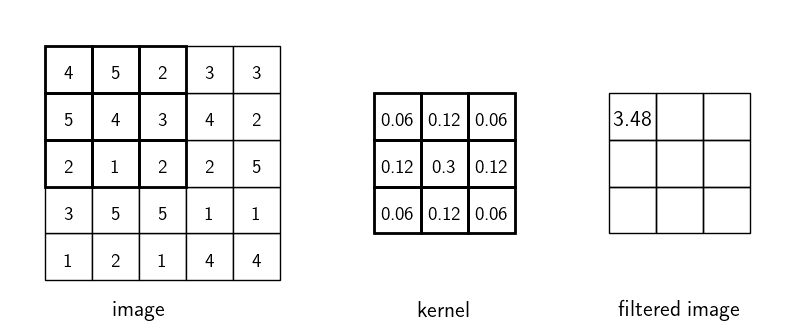

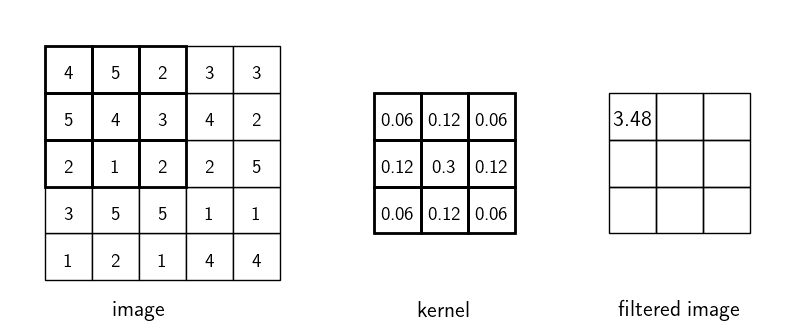

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches
from myst_nb import glue
plt.rcParams['text.usetex'] = True


def plotarray(x0, y0, X):
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            x, y = x0 + i, y0 + j
            plt.fill([x, x+w, x+w, x], [y, y, y+w, y+w], fc='w', ec='k')
            plt.text(x+0.5*w, y+0.5*w-0.2, s=f'{X[i,j]}', ha='center', fontsize=14)

            
X = np.array([[1, 3, 2, 5, 4], [2, 5, 1, 4, 5], [1, 5, 2, 3, 2], [4, 1, 2, 4, 3], [4, 1, 5 ,2, 3]])
K = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]])
K = np.around(K / np.sum(K), 2)
K[1,1] = 0.30

fig, ax = plt.subplots(figsize=(10, 4))

w = 1
x0, y0 = 0, 0
x1, y1 = 7, 1
plotarray(x0, y0, X)
plotarray(x1, y1, K)

for i in range(3):
    for j in range(3):
        plt.fill([i, i+w, i+w, i], [2+j, 2+j, 2+j+w, 2+j+w], fill=False, ec='k', lw=2)
        plt.fill([x1+i, x1+i+w, x1+i+w, x1+i], [y1+j, y1+j, y1+j+w, y1+j+w], fill=False, ec='k', lw=2)
        plt.fill([x1+5+i, x1+5+i+w, x1+5+i+w, x1+5+i], [y1+j, y1+j, y1+j+w, y1+j+w], fill=False, ec='k', lw=1)

        
plt.text(12.5, 3.3, s="3.48", fontsize=16,ha='center')
plt.text(2, -0.75, s="image", fontsize=16,ha='center')
plt.text(8.5, -0.75, s="kernel", fontsize=16,ha='center')
plt.text(13.5, -0.75, s="filtered image", fontsize=16,ha='center')
plt.axis('equal')
plt.axis('off')
plt.show()
glue("convolution-plot", fig, display=False)

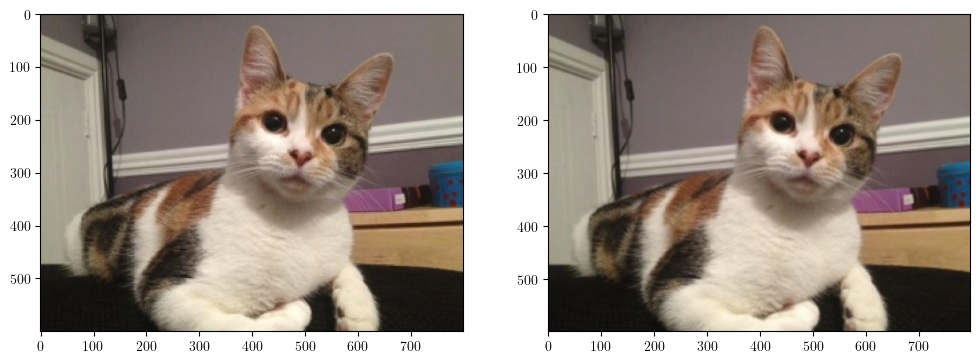

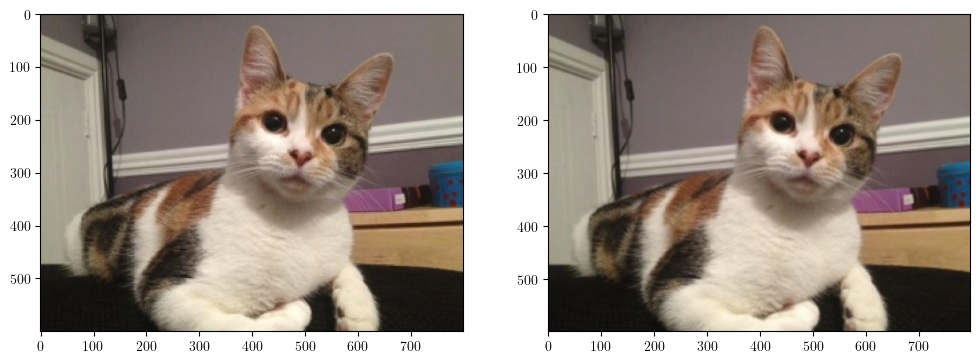

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches
from myst_nb import glue
plt.rcParams['text.usetex'] = True

def convolve(X, kernel):
    ksize = kernel.shape[0]
    Ny, Nx, _ = X.shape
    Y_Nx, Y_Ny = Nx - 2 * (ksize // 2), Ny - 2 * (ksize // 2)
    Y = np.zeros((Y_Ny, Y_Nx, 3)).astype(int)
    for i in range(Y_Ny):
        for j in range(Y_Nx):
            for k in range(3):
                Y[i,j,k] = np.sum(X[i:i+ksize,j:j+ksize,k] * kernel)               

    return Y



img1 = mpimg.imread("../images/cavendish.jpg")
blur = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]]) / 16

img2 = convolve(img1, blur)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img1)
ax[1].imshow(img2)

glue("blur-plot", fig, display=False)

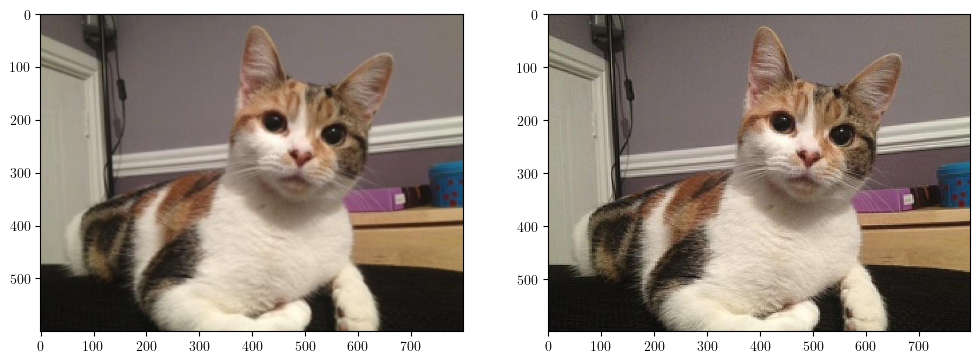

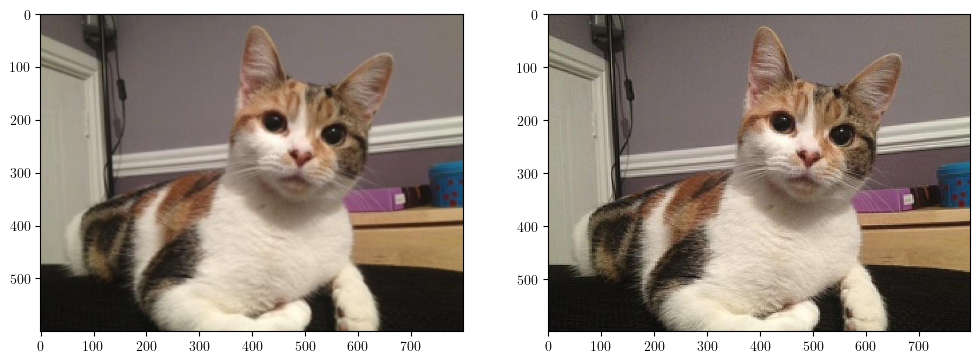

In [3]:
sharpen = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
img2 = convolve(img1, sharpen)

img2[img2 < 0] = 0
img2[img2 > 255] = 255

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img1)
ax[1].imshow(img2)

glue("sharpen-plot", fig, display=False)